# How do the Indian and UK tech markets compare?
Skills, tools, pay, and experience using the Stack Overflow Developer Survey 2025

Data sourced directly from Stack Overflow's published survey release.

In [1]:
import pandas as pd
import json
pd.set_option("display.float_format", "{:,.0f}".format)

## 1. Loading the data
49,191 respondents, 172 columns.

In [2]:
df = pd.read_csv("results.txt", low_memory=False)
df.shape

(49191, 172)

## 2. Sample sizes
Checking whether India and the UK have enough respondents to compare.

In [3]:
df["Country"].value_counts().head(20)

Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409
Canada                                                  1305
Ukraine                                                  964
Poland                                                   888
Netherlands                                              867
Italy                                                    835
Brazil                                                   825
Australia                                                804
Spain                                                    717
Sweden                                                   616
Switzerland                                              546
Czech Republic                                           520
Austria         

In [4]:
uk = df[df["Country"] == "United Kingdom of Great Britain and Northern Ireland"]
uk["DevType"].value_counts()

DevType
Developer, full-stack                            597
Developer, back-end                              319
Architect, software or solutions                 120
Other (please specify):                           97
Developer, desktop or enterprise applications     92
Student                                           83
Developer, embedded applications or devices       68
Engineering manager                               66
Developer, front-end                              66
Academic researcher                               63
Retired                                           52
Developer, mobile                                 46
DevOps engineer or professional                   40
Senior executive (C-suite, VP, etc.)              32
Data engineer                                     32
AI/ML engineer                                    31
Data scientist                                    31
Founder, technology or otherwise                  25
Developer, game or graphics           

In [5]:
india = df[df["Country"] == "India"]
india["DevType"].value_counts()

DevType
Developer, full-stack                            695
Developer, back-end                              383
Student                                          359
Developer, front-end                             164
Architect, software or solutions                 155
Developer, mobile                                145
AI/ML engineer                                    61
Developer, desktop or enterprise applications     61
Other (please specify):                           60
Engineering manager                               49
Data engineer                                     47
DevOps engineer or professional                   42
Developer, embedded applications or devices       33
Data scientist                                    33
Academic researcher                               28
Data or business analyst                          25
Senior executive (C-suite, VP, etc.)              23
Founder, technology or otherwise                  23
Developer, QA or test                 

### Why this isn't a data-roles comparison

I first considered filtering with only data roles specifically. Ruled it out because UK data roles totalled ~112 respondents (data scientist, data analyst, data engineer, AI/ML engineer, etc combined) —> too few for reliable testing.

Reframed to a full-market comparison instead —> 2,547 India vs 2,042 UK.

### Checking for duplicates

In [6]:
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


## 3. Salary Comparison between the two countries

A "tech market" indicates the people working in it, hence excluding students and retired respondents. 

India had 359 students vs 83 in the UK, so leaving them in would skew pay and experience. Using ConvertedCompYearly (in USD) rather than CompTotal (local currency).

In [7]:
[c for c in df.columns if "Comp" in c]

['CompTotal', 'AIComplex', 'ConvertedCompYearly']

In [8]:
working = df[~df["DevType"].isin(["Student", "Retired"])]

countries = ["India", "United Kingdom of Great Britain and Northern Ireland"]

(working[working["Country"].isin(countries)]
 .groupby("Country")["ConvertedCompYearly"]
 .agg(["size", "count", "median"]))

,size,count,median
Country,,,
India,2182,1071,"17,436"
United Kingdom of Great Britain and Northern Ireland,1907,1465,"95,299"


### Observations

- India: 1071 of 2182 reported a salary (49%)
- UK: 1465 of 1907 reported a salary (77%)
- Half of Indian respondents skipped the salary question, so the Indian median only reflects the half who chose to answer.
- India vs UK Medians: $17,436 vs $95,299 (~5.5x)

## 4. Checking for unrealistic salary values

Survey salary data usually contains a few impossible numbers. Eg.: people typing a monthly figure as annual or adding extra zeros. Checking the range before using these values in charts.

In [9]:
india = working[working["Country"] == "India"]["ConvertedCompYearly"].dropna()
uk = working[working["Country"] == countries[1]]["ConvertedCompYearly"].dropna()

pd.DataFrame({
    "India": india.describe(),
    "UK": uk.describe()
})

,India,UK
count,"1,071","1,465"
mean,"45,205","114,129"
std,"310,266","151,007"
min,1,5
25%,"6,974","66,709"
50%,"17,436","95,299"
75%,"40,394","133,419"
max,"9,531,653","4,706,124"


### Removing unlikely values

The highest salary recorded was $9.5 million, which is over 200 times what three-quarters of people earn, while the lowest was $1. These seem to be data entry mistakes, not real salaries.

I have kept only the salaries between $1,000 and $500,000 a year. Anything outside this range is most likely a mistake, such as, typing a monthly figure as yearly or adding extra zeros.

In [10]:
def clean_salary(s):
    return s[(s >= 1000) & (s <= 500000)]

india_clean = clean_salary(india)
uk_clean = clean_salary(uk)

print(f"India: {len(india)} → {len(india_clean)}  ({len(india) - len(india_clean)} removed)")
print(f"UK:    {len(uk)} → {len(uk_clean)}  ({len(uk) - len(uk_clean)} removed)")

pd.DataFrame({"India": india_clean.describe(), "UK": uk_clean.describe()})

India: 1071 → 1031  (40 removed)
UK:    1465 → 1443  (22 removed)


,India,UK
count,"1,031","1,443"
mean,"30,446","106,814"
std,"39,616","59,303"
min,"1,162","2,723"
25%,"7,556","68,071"
50%,"18,598","95,299"
75%,"40,684","132,057"
max,"500,000","462,881"


### Updates

Removed 40 Indian and 22 UK responses, which is about 2% of the data.

India's standard deviation dropped from 310,266 to 39,616, and the average fell from $45,205 to $30,446. Therefore, a few fake entries earlier were pulling the average up by roughly $15,000.

The median moved very minimally, from $17,436 to $18,598. That's why I'm using medians rather than averages; they aren't changing much due to a handful of extreme values.

Clean comparison: $18,598 in India vs $95,299 in the UK, about 5x.

## 5. Skills and tools

The survey asks what languages, databases and tools people use. Each answer is stored as one long text string with semicolons between items, so they need splitting before anything can be counted.

In [11]:
skill_cols = [c for c in df.columns if "HaveWorkedWith" in c]
skill_cols

['LanguageHaveWorkedWith',
 'DatabaseHaveWorkedWith',
 'PlatformHaveWorkedWith',
 'WebframeHaveWorkedWith',
 'DevEnvsHaveWorkedWith',
 'SOTagsHaveWorkedWith',
 'OfficeStackAsyncHaveWorkedWith',
 'CommPlatformHaveWorkedWith',
 'AIModelsHaveWorkedWith']

In [12]:
df["LanguageHaveWorkedWith"].head(3).tolist()

['Bash/Shell (all shells);Dart;SQL',
 'Java',
 'Dart;HTML/CSS;JavaScript;TypeScript']

### Splitting the skills columns

The answer is one long string separated by semi-colons, like 'Bash/Shell (all shells);Dart;SQL','Java','Dart;HTML/CSS;JavaScript;TypeScript'. Splitting the string on the semicolons gives one row per person per skill, which can then be counted.

Since India has more respondents than the UK, I am using percentages rather than raw counts.

In [13]:
def skill_counts(data, column):
    """Split semicolon-separated skills and count how many people use each."""
    exploded = data[column].dropna().str.split(";").explode()
    counts = exploded.value_counts()
    return (counts / len(data[column].dropna()) * 100).round(1)

india_data = working[working["Country"] == "India"]
uk_data = working[working["Country"] == countries[1]]

skill_counts(india_data, "LanguageHaveWorkedWith").head(10)

LanguageHaveWorkedWith
JavaScript                69
HTML/CSS                  59
SQL                       56
Python                    54
TypeScript                43
Java                      37
Bash/Shell (all shells)   31
C++                       22
C                         20
PHP                       18
Name: count, dtype: float64

### Checking the experience columns

These should be numbers, but survey forms often store text answers like "Less than 1 year" in the same column. Checking before using them in any calculation.

In [14]:
print(df["YearsCode"].unique()[:20])
print()
print(df["WorkExp"].unique()[:20])

[14. 10. 12.  5. 22. 20. 13. 30. 15.  9.  6. nan  3. 40.  8. 45. 35. 11.
  7. 47.]

[ 8.  2. 10.  4. 21. 15.  9. 22.  7.  3.  6.  5. 20.  1. 40. 35. 37. 26.
 24. 13.]


Both columns are already numeric; no text values mixed in. The only missing entries are from people who skipped the question. Nothing to
clean here.

### 6. Comparing skills between the two countries

Same calculation for both countries, side by side. The difference column shows where the two markets diverge most: positive means more common in India, negative means more common in the UK.

In [15]:
def compare_skills(column, top_n=15):
    ind = skill_counts(india_data, column)
    uk = skill_counts(uk_data, column)
    out = pd.DataFrame({"India": ind, "UK": uk})
    out["difference"] = (out["India"] - out["UK"]).round(1)
    out["max_usage"] = out[["India", "UK"]].max(axis=1)
    return out.sort_values("max_usage", ascending=False).drop(columns="max_usage").head(top_n)

compare_skills("LanguageHaveWorkedWith")

,India,UK,difference
LanguageHaveWorkedWith,,,
JavaScript,69,67,2
HTML/CSS,59,62,-3
SQL,56,61,-5
Python,54,54,1
Bash/Shell (all shells),31,50,-19
TypeScript,43,42,2
Java,37,22,15
C#,17,34,-17
PowerShell,15,26,-11


### Results of the language comparison

The most-used languages are nearly identical in both countries. JavaScript, HTML/CSS, SQL and Python are within a few points of each
other. So, we can say that the core stack is the same regardless of market.

The differences are in four languages:

- Java: 37% India vs 22% UK
- Bash/Shell: 31% India vs 50% UK
- C#: 17% India vs 34% UK
- PowerShell: 15% India vs 26% UK

C# and PowerShell being higher in the UK may point to more Microsoft and .NET work there. Java being higher in India would fit its large
IT services sector.

### Databases

In [16]:
compare_skills("DatabaseHaveWorkedWith")

,India,UK,difference
DatabaseHaveWorkedWith,,,
MySQL,58,36,22
PostgreSQL,54,52,2
MongoDB,45,17,28
Microsoft SQL Server,26,36,-10
SQLite,31,34,-3
Redis,31,26,5
MariaDB,15,18,-3
Elasticsearch,17,17,1
Dynamodb,12,13,-1


### Cloud platforms

In [17]:
compare_skills("PlatformHaveWorkedWith")

,India,UK,difference
PlatformHaveWorkedWith,,,
Docker,62,69,-7
npm,55,55,0
Amazon Web Services (AWS),54,52,3
Pip,39,36,3
Microsoft Azure,25,34,-9
Google Cloud,33,24,9
Kubernetes,26,26,0
Homebrew,19,25,-6
Terraform,13,25,-12


### Editors and IDEs

In [18]:
compare_skills("DevEnvsHaveWorkedWith")

,India,UK,difference
DevEnvsHaveWorkedWith,,,
Visual Studio Code,84,77,7
Visual Studio,28,34,-6
Notepad++,31,30,2
IntelliJ IDEA,30,22,8
Cursor,26,14,12
Android Studio,22,10,12
Vim,19,22,-2
PyCharm,19,14,5
Jupyter Notebook/JupyterLab,18,12,6


### A pattern across all four comparisons

The UK consistently uses more Microsoft tools:

- C# (34% vs 17%) and PowerShell (26% vs 15%)
- Microsoft SQL Server (36% vs 26%)
- Azure (34% vs 25%)
- NuGet, the .NET package manager (24% vs 11%)

India leans toward a different stack:

- MongoDB (45% vs 17%) — the largest single gap found
- MySQL (58% vs 36%)
- Firebase and Cloud Firestore
- Google Cloud (33% vs 24%)

AWS, PostgreSQL, Docker, npm and Kubernetes are used at almost identical rates in both countries.  

Two editors show the largest gaps, both 12 points apart:

- Cursor: 26% India vs 14% UK —> an AI-focused editor
- Android Studio: 22% India vs 10% UK —> mobile development

Android Studio fits with Java being higher in India (37% vs 22%), since Android development uses Java and Kotlin. 

I'm following through with Cursor rather than Android Studio because the survey has a set of questions about AI tool use, therefore it's something I can test. There's no equivalent set of questions about mobile development.

## 7. Experience levels

Comparing how long people have been coding vs how long they've been working professionally.

In [19]:
exp_cols = ["YearsCode", "WorkExp"]

pd.DataFrame({
    "India": india_data[exp_cols].median(),
    "UK": uk_data[exp_cols].median()
})

,India,UK
YearsCode,8,19
WorkExp,6,15


## 8. Salary compared at the same experience level

UK respondents have more than twice the experience of Indian ones: 19 years coding vs 8, and 15 years working vs 6. So the raw salary
comparison compares a mid-career Indian respondent to a senior UK one.

Splitting both countries into experience bands to compare people at similar career stages.

In [20]:
def salary_by_experience(data):
    d = data[data["ConvertedCompYearly"].between(1000, 500000)].copy()
    d["exp_band"] = pd.cut(d["WorkExp"],
                           bins=[0, 3, 6, 10, 20, 50],
                           labels=["0-3", "4-6", "7-10", "11-20", "20+"])
    return d.groupby("exp_band", observed=True)["ConvertedCompYearly"].agg(["count", "median"])

pd.concat({"India": salary_by_experience(india_data),
           "UK": salary_by_experience(uk_data)}, axis=1)

India           UK        
         count median count  median
exp_band                           
0-3        308  8,137   136  50,890
4-6        217 15,111   159  73,516
7-10       213 30,222   225  91,215
11-20      215 44,462   467 108,913
20+         40 47,658   447 108,913

### Results of comparing with experience

The raw 5x salary gap was misleading, because the two samples aren't comparable. UK respondents are much more senior.

Comparing people at the same career stage:

- 0-3 years:  $8,137 vs $50,890  (6.3x)
- 4-6 years:  $15,111 vs $73,516 (4.9x)
- 7-10 years: $30,222 vs $91,215 (3.0x)
- 11-20 years: $44,462 vs $108,913 (2.4x)
- 20+ years:  $47,658 vs $108,913 (2.3x)

The gap is widest at entry level and narrows steadily with experience.

Indian salaries also flatten early: $44,462 at 11-20 years rises to only $47,658 at 20+. UK salaries flatten too, but at a much higher level.

The samples themselves differ: India has 308 respondents with 0-3 years and 40 with 20+. The UK has 136 and 447. These are very different
workforce profiles.

All figures are raw US dollars and don't account for cost of living.

## 9. Checking what AI-related questions the survey asked

In [21]:
[c for c in df.columns if c.startswith("AI")]

['AILearnHow',
 'AIThreat',
 'AIModelsChoice',
 'AIModelsHaveWorkedWith',
 'AIModelsWantToWorkWith',
 'AIModelsAdmired',
 'AIModelsHaveEntry',
 'AIModelsWantEntry',
 'AISelect',
 'AISent',
 'AIAcc',
 'AIComplex',
 'AIToolCurrently partially AI',
 "AIToolDon't plan to use AI for this task",
 'AIToolPlan to partially use AI',
 'AIToolPlan to mostly use AI',
 'AIToolCurrently mostly AI',
 'AIFrustration',
 'AIExplain',
 'AIAgents',
 'AIAgentChange',
 'AIAgent_Uses',
 'AIAgentImpactSomewhat agree',
 'AIAgentImpactNeutral',
 'AIAgentImpactSomewhat disagree',
 'AIAgentImpactStrongly agree',
 'AIAgentImpactStrongly disagree',
 'AIAgentChallengesNeutral',
 'AIAgentChallengesSomewhat disagree',
 'AIAgentChallengesStrongly agree',
 'AIAgentChallengesSomewhat agree',
 'AIAgentChallengesStrongly disagree',
 'AIAgentKnowledge',
 'AIAgentKnowWrite',
 'AIAgentOrchestration',
 'AIAgentOrchWrite',
 'AIAgentObserveSecure',
 'AIAgentObsWrite',
 'AIAgentExternal',
 'AIAgentExtWrite',
 'AIHuman',
 'AIOpen'

## 10. Statistical test —> How does AI tool adoption differ between the two countries?

Unlike the salary and experience gaps, AI adoption is uncertain. Since the survey has an entire set of question regarding it, it is something I can test.

AISelect asks whether people use AI tools in their development process. The answers are categories rather than numbers, which suits a chi-square test. This checks whether two categorical things are related. Here it checks whether a country someone is in is related to their usage of AI tools.

In [22]:
print(india_data["AISelect"].value_counts())
print()
print(uk_data["AISelect"].value_counts())

AISelect
Yes, I use AI tools daily                      1199
Yes, I use AI tools weekly                      289
Yes, I use AI tools monthly or infrequently     214
No, but I plan to soon                          151
No, and I don't plan to                          99
Name: count, dtype: int64

AISelect
Yes, I use AI tools daily                      690
No, and I don't plan to                        481
Yes, I use AI tools weekly                     294
Yes, I use AI tools monthly or infrequently    277
No, but I plan to soon                          95
Name: count, dtype: int64


In [23]:
from scipy.stats import chi2_contingency

ai = pd.crosstab(
    working[working["Country"].isin(countries)]["Country"],
    working[working["Country"].isin(countries)]["AISelect"]
)

chi2, p, dof, expected = chi2_contingency(ai)

print(ai)
print()
print(f"chi-square = {chi2:.2f}")
print(f"p-value    = {p:.6f}")

AISelect                                            No, and I don't plan to  \
Country                                                                       
India                                                                    99   
United Kingdom of Great Britain and Northern Ir...                      481   

AISelect                                            No, but I plan to soon  \
Country                                                                      
India                                                                  151   
United Kingdom of Great Britain and Northern Ir...                      95   

AISelect                                            Yes, I use AI tools daily  \
Country                                                                         
India                                                                    1199   
United Kingdom of Great Britain and Northern Ir...                        690   

AISelect                                     

### Putting the same numbers as percentages

Converting each row to percentages to show what share of each country's respondents gave each answer.

In [24]:
both = working[working["Country"].isin(countries)]
pd.crosstab(both["Country"], both["AISelect"], normalize="index").round(3) * 100

AISelect,"No, and I don't plan to","No, but I plan to soon","Yes, I use AI tools daily","Yes, I use AI tools monthly or infrequently","Yes, I use AI tools weekly"
Country,,,,,
India,5,8,61,11,15
United Kingdom of Great Britain and Northern Ireland,26,5,38,15,16


### Results of the Statistical test

chi-square = 406.50, p-value = 0.000000

The p-value is effectively zero. So, we can say that AI tool use is significantly different in the two countries.

- Uses AI tools daily: 65% in India vs 38% in the UK
- Don't plan to use AI at all: 5% in India vs 26% in the UK


The weekly and occasional usage are almost identical in both countries. Conversely, Indians use AI tools daily at nearly twice the rate of UK rate, while UK respondents are around five times more likely to reject AI tools completely.

This is the largest difference found in the comparison.

Since the survey doesn't convey why the difference exists, I have left it there rather than guessing.

## 11. Charts

### 11.1 Salary compared at the same experience level

This is the clearest finding from the analysis, hence displaying it as a chart.

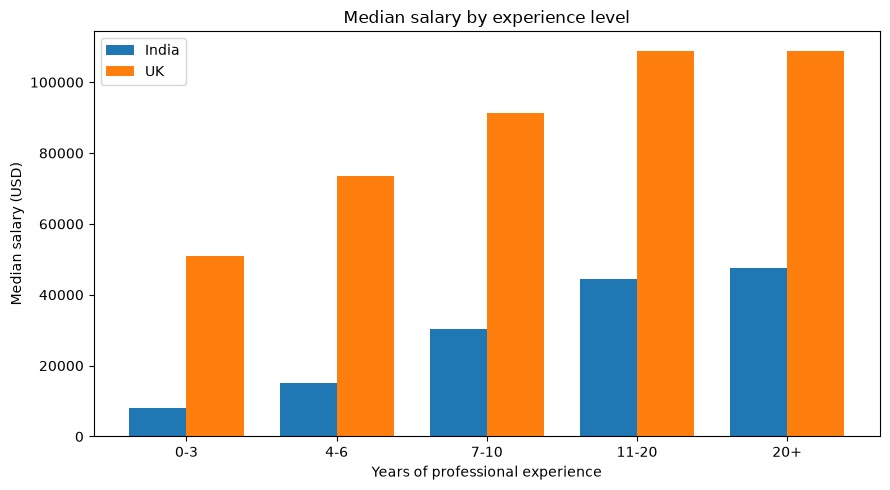

In [25]:
import matplotlib.pyplot as plt

salary_by_exp = pd.concat({
    "India": salary_by_experience(india_data),
    "UK": salary_by_experience(uk_data)
}, axis=1)

bands = salary_by_exp.index.tolist()
india_med = salary_by_exp[("India", "median")]
uk_med = salary_by_exp[("UK", "median")]

x = range(len(bands))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x], india_med, width, label="India")
ax.bar([i + width/2 for i in x], uk_med, width, label="UK")

ax.set_xticks(list(x))
ax.set_xticklabels(bands)
ax.set_xlabel("Years of professional experience")
ax.set_ylabel("Median salary (USD)")
ax.set_title("Median salary by experience level")
ax.legend()
plt.tight_layout()
plt.savefig("chart-salary-experience.png", dpi=150)
plt.show()

### 11.2 Skills and tools compared

Diplaying Programming languages, Databases and Cloud platforms used using the same chart style for all three, so that they're easy to compare.

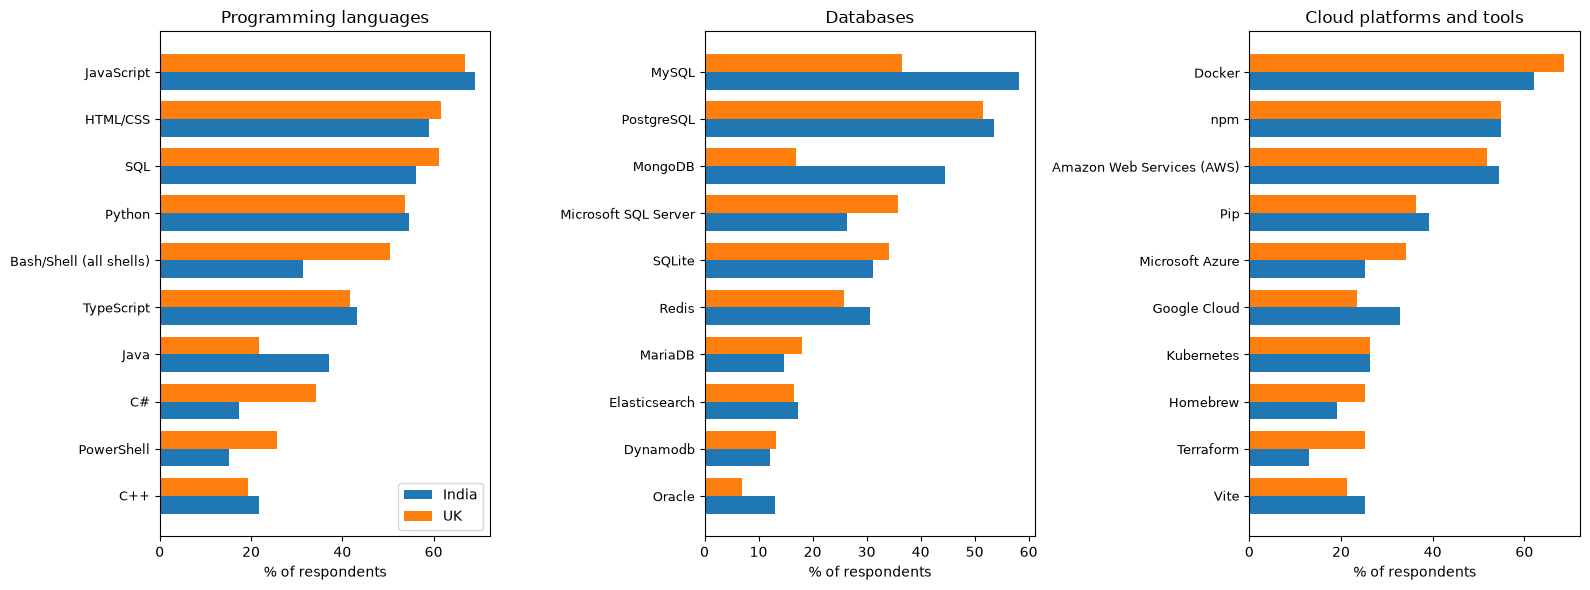

In [26]:
charts = [
    ("LanguageHaveWorkedWith", "Programming languages"),
    ("DatabaseHaveWorkedWith", "Databases"),
    ("PlatformHaveWorkedWith", "Cloud platforms and tools"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (column, title) in zip(axes, charts):
    data = compare_skills(column, top_n=10)
    y = range(len(data))
    height = 0.38

    ax.barh([i + height/2 for i in y], data["India"], height, label="India")
    ax.barh([i - height/2 for i in y], data["UK"], height, label="UK")

    ax.set_yticks(list(y))
    ax.set_yticklabels(data.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("% of respondents")
    ax.set_title(title)

axes[0].legend()
plt.tight_layout()
plt.savefig("chart-skills-comparison.png", dpi=150)
plt.show()

### 11.3 Distributions

The previous charts compare averages. The following charts illustrate the spread how salary and experience are actually distributed within each country.

Box plots show the median as a line, the middle 50% as the box, and the range as the lines extending out.

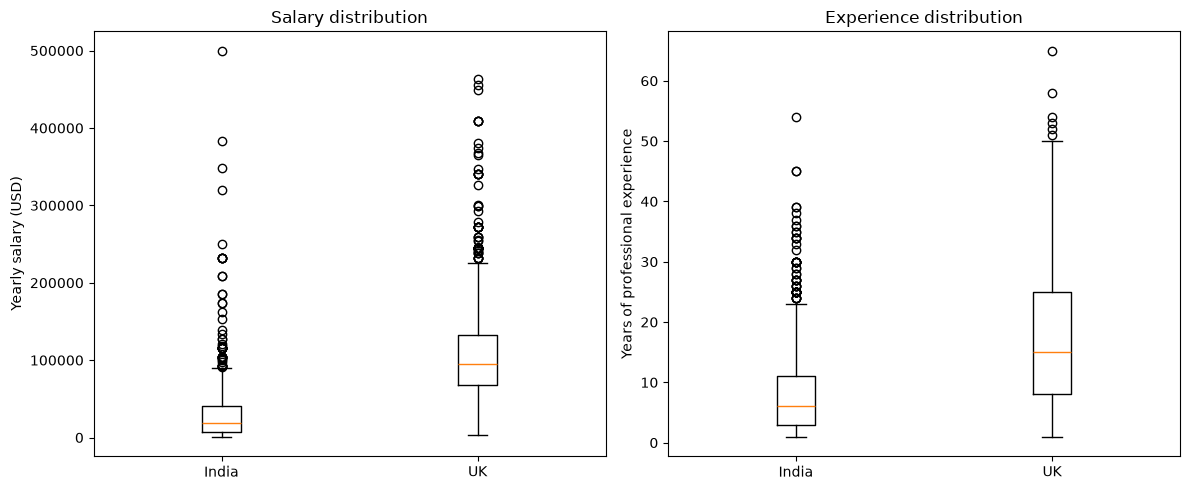

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Salary
axes[0].boxplot([india_clean, uk_clean], tick_labels=["India", "UK"])
axes[0].set_ylabel("Yearly salary (USD)")
axes[0].set_title("Salary distribution")

# Experience
india_exp = india_data["WorkExp"].dropna()
uk_exp = uk_data["WorkExp"].dropna()

axes[1].boxplot([india_exp, uk_exp], tick_labels=["India", "UK"])
axes[1].set_ylabel("Years of professional experience")
axes[1].set_title("Experience distribution")

plt.tight_layout()
plt.savefig("chart-distributions.png", dpi=150)
plt.show()

## 12. Standard data quality checks

Running the data quality checks here to keep them in one place.

### 12.1 To see what the data looks like

In [28]:
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging","61,256",10
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,"104,413",9
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...","53,061",8
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,"36,197",6
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...","60,000",7


### 12.2 Column types

In [29]:
df.dtypes.value_counts()

str        119
float64     52
int64        1
Name: count, dtype: int64

### 12.3 Missing values in the columns used

In [30]:
cols = ["Country", "DevType", "ConvertedCompYearly", "WorkExp", "YearsCode", "AISelect"]
pd.DataFrame({
    "missing": df[cols].isnull().sum(),
    "% missing": (df[cols].isnull().sum() / len(df) * 100).round(1)
})

,missing,% missing
Country,13754,28
DevType,5511,11
ConvertedCompYearly,25244,51
WorkExp,6298,13
YearsCode,6149,12
AISelect,15471,32


Almost half the survey skipped the salary question (51%), and 28% didn't give a country. It is necessary to mention that every figure here
is based on people who chose to answer and not the full sample.

Wherever values were missing, I chose to leave them out instead of filling them in. Since the project compares salaries between two countries, filling up empty values would mean comparing figures that were invented and not true.

### 12.4 Checking against the standard outlier method

The usual way to find outliers is the IQR (Interquartile Range) method. It takes the middle 50% of values, then extends outward from both ends by 1.5 times that range. Anything beyond that is treated as an outlier.

Earlier I used fixed cutoffs by removing salaries below $1,000 and above $500,000, which I chose myself. Using the standard method here to see what limits it would have chosen, and whether mine were reasonable.

In [31]:
for name, data in [("India", india), ("UK", uk)]:
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    print(f"{name}: IQR method would cut below {q1 - 1.5*iqr:,.0f} and above {q3 + 1.5*iqr:,.0f}")

India: IQR method would cut below -43,155 and above 90,523
UK: IQR method would cut below -33,356 and above 233,484


### Results of using standard outlier method

The IQR method would have used very different cutoffs for each country — $90,523 for India and $233,484 for the UK.

That would have posed a problem for a comparison. An Indian respondent earning $95,000 would be deleted as an outlier, while a UK respondent earning $230,000 would be kept. The same salary would be treated as real in one country
and an error in the other.

My fixed cutoffs ($1,000 to $500,000) apply the same rule to both countries. They only remove values that are impossible as annual
salaries anywhere, rather than values that are unusual for one country.

The IQR method here is unsuitable for a comparison between two groups with very different distributions.

### 12.5 Does more experience mean more pay?

Correlation measures how closely two things move together. It runs from -1 to 1: closer to 1 means salary rises reliably with experience, closer to 0 means there's little connection.

In [32]:
for name, data in [("India", india_data), ("UK", uk_data)]:
    d = data[data["ConvertedCompYearly"].between(1000, 500000)]
    r = d["WorkExp"].corr(d["ConvertedCompYearly"])
    print(f"{name}: correlation between experience and salary = {r:.2f}")

India: correlation between experience and salary = 0.35
UK: correlation between experience and salary = 0.20


### Results of correlation

Both numbers are moderate. We can say that experience affects pay, but it's clearly not the only thing that matters. Role, company, and location all play a part and aren't captured here.

The correlation is higher in India (0.35) than the UK (0.20). This fits the earlier finding: Indian salaries rose steadily across the experience bands, while UK salaries flattened out after 11 years. When pay stops rising with experience, the connection between them weakens.

## 13. Excel dashboard

Exporting a summary table to Excel and building a dashboard with live formulas (Not the entire data of 49,000 rows).

In [33]:
EXPORT ALREADY DONE - see note below. Uncomment only if rebuilding from scratch.

# with pd.ExcelWriter("dashboard-data.xlsx") as writer:
    # salary by experience band
    #salary_by_exp.to_excel(writer, sheet_name="Salary by experience")

    # the three skills comparisons
    #compare_skills("LanguageHaveWorkedWith", top_n=10).to_excel(writer, sheet_name="Languages")
    #compare_skills("DatabaseHaveWorkedWith", top_n=10).to_excel(writer, sheet_name="Databases")
    #compare_skills("PlatformHaveWorkedWith", top_n=10).to_excel(writer, sheet_name="Platforms")

    # AI adoption percentages
    #ai_pct = pd.crosstab(both["Country"], both["AISelect"], normalize="index").round(3) * 100
    #ai_pct.to_excel(writer, sheet_name="AI adoption")

#print("Saved dashboard-data.xlsx")

SyntaxError: invalid syntax (3369097206.py, line 1)

The file exported here was renamed to india-uk-dashboard.xlsx, and the Dashboard sheet with live formulas and a chart was built in on top of it.

Do not re-run the cell above. It would write a fresh copy of dashboard-data.xlsx containing only the raw summary tables, and the
dashboard work would need rebuilding.